# Job Shop Scheduling

In this notebook we create a job shop scheduling problem, formulate it in a way suitable for approach by quantum computers, and solve using a variety of methods.

We also explore the resource requirements, scaling, and benchmarking across a random problem set.

## Introduction

Our methods are drawn from Google[^1] and Schmid et al.[^2].
[^1]: [https://developers.google.com/optimization/scheduling/job_shop](https://developers.google.com/optimization/scheduling/job_shop)
[^2]: [https://arxiv.org/pdf/2401.16381](https://arxiv.org/pdf/2401.16381)

We have a set of tasks $T$. Each task $t$ has a machine $m$, a duration $d$, and a set of parent tasks which must be completed before that task can be begun, $P$. Our goal is to minimise the makespan: the time at which the last task finishes.

> This is a generalisation of the usual problem, where each job has a series of sequential tasks; our formulation, allowing arbitrary dependencies, includes this as a special case.

Our problem of minimising the makespan is subject to seeral constraints:

- one start time per task
- a task starts only after all parents have finished
- one task per machine at a given time

## Notes

There are a few free wins we can take:

- **start-time windows**
    - task $i$ cannot start before the parent tasks have finished, and cannot start so late that following work does not fit
    - therefore at both ends, we take the better bound of the critical path, and the busiest machine's total load
    - $\text{earliest}(i) = \max\left(\max_{p\,\in\,P(i)} \big(\text{earliest}(p) + d_p\big),\; \max_m \sum_{a\,\in\,A(i),\; m_a = m} d_a\right)$
    - $\text{tail}(i) = \max\left(d_i + \max_{c\text{ child of } i} \text{tail}(c),\; \max_m \sum_{c\,\in\,C(i)\,\cup\,\{i\},\; m_c = m} d_c\right)$, and $\text{latest}(i) = \text{horizon} - \text{tail}(i)$
    - the makespan is at least $\max_i\left(\text{earliest}(i) + \text{tail}(i)\right)$, and at least the busiest machine's total load
    - this is useful for reducing the problem size as some variables are immediately eliminated
- **makespan task**
    - our naive objective would be to minimise the maximum start time; which can't be a QUBO
    - therefore, we add a dummy makespan task which has every childless task as a partent and has zero duration
    - then, the start time of this task is the solution's makespan, and we can just minimise this!

Note also that we report two metrics alongside p(optimum):

- TTS, the wall-clock time for the whole solve
- reps99 (`ln(0.01) / ln(1 - p)`), the number of runs (reads or shots) needed to see an optimal solution at least once with 99% confidence, where `p` is the fraction of runs which hit the optimum; set against the runs actually drawn, it shows whether the shot count can come down or needs to go up

A run counts as feasible only if every task has exactly one start time set and the resulting schedule meets every constraint; a sample that breaks one-hot is never repaired.


## Problem Generation

Each task is defined as a tuple of indices: `(machine, duration, dependencies)`.

We use a small example, or we can also load the smallest instance from [`JobShopLib`](https://job-shop-lib.readthedocs.io/en/stable/index.html)'s benchmarking set.

In [1]:
from dwave.samplers import PathIntegralAnnealingSampler
from main import (
    AnnealingSolver,
    ExactSolver,
    GreedySolver,
    GurobiSolver,
    LRQAOASolver,
    Problem,
    QAOASolver,
    build_formulation,
)
from qiskit_aer import AerSimulator

random-None problem
 * tasks        : 6
 * machines     : 3
 * dependencies : 8
 * makespan     : between 11 and 13
 * optimum      : unknown


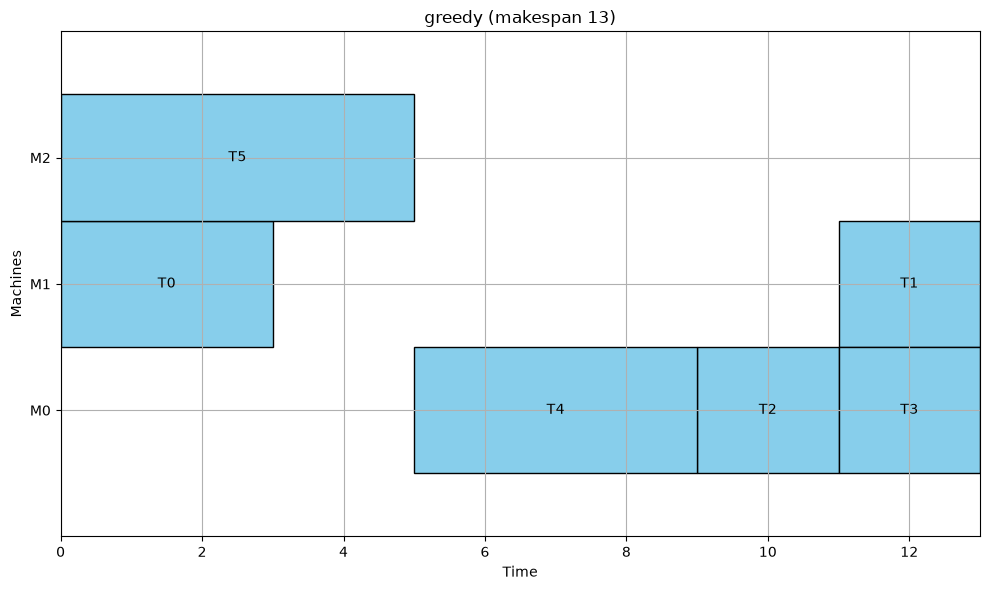

In [7]:
# example problem
tasks = [
    (0,3,()),
    (1,1,()),
    (2,2,()),
    (1,5,(0,1)),
    (2,2,(2,)),
    (0,1,(3,)),
    (2,1,(3,4,5))
]
problem = Problem(name="example", tasks=tasks)

# smallest problem from JobShopLib
# problem = Problem.load("ft06")

# random problem
problem = Problem.random(
    num_tasks=6,
    num_machines=3,
    min_parents=2,
    max_parents=2,
    min_duration=1,
    max_duration=5,
    )

# problem details
problem.describe()

# and a visual
problem.draw()

## Formulation

We now need to formulate this optimisation problem as a QUBO, so we can solve it using quantum methods.

We use a one-hot encoding as it is the simplest, although other encodings (binary, domain-wall) might improve performance at the cost of complexity.

Each variable $x_{ij}$ refers to task $i$ being carried out at time $j$. Only those times are allowed which are within the window for that task (see above).

Our objective is simply the start time of the makespan task:

$$\text{objective}=\sum_j{jx_{mj}},\quad j\in \text{makespan window}$$

Note that this is a simple linear objective.

Our above constraints can be included via architecture or penalties:

- one start time per task means that of all the variables for a given task, only one is nonzero. This can be done via an additional one-hot penalty per task, which scales linearly, or via a block-encoded weight-preserving mixer for QAOA. If we were to use the domain-wall encoding for annealing, this would also be automatic
- one task per machine at a given time: iterate over all variables on a given machine and penalise those which would cause overlaps
- every parent finishes before its child starts: iterate over each parent-child relationship and penalise infeasible combinations

Note that since the energy of the QUBO is limited to the horizon, the penalty can just be the horizon $+1$!

Also note that this formulation conversion is carried out within each solver as required.

In [9]:
# get QUBO matrix
formulation = build_formulation(problem)

# describe
formulation.describe()

QUBO formulation
 * variables       : 25
 * linear terms    : 25
 * quadratic terms : 81
 * horizon         : 13
 * penalty         : 14
 * offset          : 98


## Classical Solution

We will solve with a number of methods:

- a greedy solver which returns a rapid heuristic solution
- an exact solver which enumerates all possible solutions and returns the best (only suitable for small problems)
- a srong classical solver which can solve the problem directly, or which can solve the QUBO (used for validation)

In [10]:
solver = GreedySolver()
solver.estimate(problem)
result = solver.solve(problem)
result.describe()

greedy result FEASIBLE
 * makespan     : 13
 * TTS          : 0.00018549998640082777
 * p(optimum)   : None
 * reps99       : None
 * calls        : 1
 * metadata     : {}


In [11]:
solver = ExactSolver()
result = solver.solve(problem)
result.describe()

exact result FEASIBLE
 * makespan     : 13
 * TTS          : 0.012154700001701713
 * p(optimum)   : 1.0
 * reps99       : 1.0
 * calls        : 2025
 * metadata     : {
    "calls_unit": "combinations",
    "combinations": 2025,
    "variables": 22,
    "couplings": 0,
    "proven_optimal": true
}


In [12]:
solver = GurobiSolver()
result = solver.solve(problem, method="milp")
result.describe()

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 235U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 18 rows, 11 columns and 44 nonzeros (Min)
Model fingerprint: 0xdadf36d7
Model has 1 linear objective coefficients
Variable types: 0 continuous, 11 integer (4 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+01]
  RHS range        [2e+00, 1e+01]

Found heuristic solution: objective 13.0000000
Presolve removed 18 rows and 11 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.03 seconds (0.00 work units)
Thread count was 1 (of 14 available processors)

Solution count 1: 13 

Optimal solution found (tolerance 1.00e-04)
Best

In [13]:
solver = GurobiSolver()
result = solver.solve(problem, method="qubo")
result.describe()

Gurobi Optimizer version 13.0.3 build v13.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 5 235U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 0 rows, 25 columns and 0 nonzeros (Min)
Model fingerprint: 0x1ae532b9
Model has 0 linear objective coefficients and an objective constant of 98
Model has 103 quadratic objective terms
Variable types: 0 continuous, 25 integer (25 binary)
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [2e+00, 6e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [0e+00, 0e+00]

Found heuristic solution: objective 98.0000000
Found heuristic solution: objective 26.0000000
Found heuristic solution: objective 25.0000000
Found heuristic solution: objective 13.0000000
Presolve time: 0.01s
Presolved: 78 rows, 103 columns, 234 nonzeros
Variable types: 0 continuous, 103 integer (103 binar

## Variational Solution

Here we solve the problem QUBO using gate-based variational methods on the Aer backend, as well as a real IBM device.

In [14]:
backend = AerSimulator()
solver = QAOASolver(backend)
result = solver.solve(problem, p=3)
result.describe()

KeyboardInterrupt: 

In [ ]:
backend = AerSimulator()
solver = LRQAOASolver(backend)
result = solver.solve(problem)
result.describe()

lr-qaoa/aer_simulator result FEASIBLE
 * makespan     : 10
 * TTS          : 0.7321732999989763
 * TTS99        : 0.0037935345657611396
 * p(optimum)   : 0.195068359375
 * calls        : 1
 * metadata     : {
    "calls_unit": "circuit executions",
    "backend": "aer_simulator",
    "qubits": 20,
    "p": 10,
    "shots": 4096,
    "feasible_fraction": 0.195068359375,
    "delta_gamma": 0.6,
    "delta_beta": 0.3,
    "depth": 207,
    "two_qubit_gates": 666
}


In [15]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy()

solver = LRQAOASolver(backend)
result = solver.solve(problem)
result.describe()

account.list_instances:WARNING:2026-09-24 11:28:27,103: The plan and pricing type for instance crn:v1:bluemix:public:quantum-computing:eu-de:a/d4f95db0515b47b7ba61dba8a424f873:49398475-182b-4f33-ba3d-9bee3612711b:: could not be retrieved.
account.list_instances:WARNING:2026-09-24 11:28:27,215: The plan and pricing type for instance crn:v1:bluemix:public:quantum-computing:eu-de:a/d4f95db0515b47b7ba61dba8a424f873:555f5b89-9574-467e-8283-3b7f0d03fe7f:: could not be retrieved.
account.list_instances:WARNING:2026-09-24 11:28:27,436: The plan and pricing type for instance crn:v1:bluemix:public:quantum-computing:us-east:a/d4f95db0515b47b7ba61dba8a424f873:294c352c-cc8d-4c70-9da6-410f2942fdc6:: could not be retrieved.
account.list_instances:WARNING:2026-09-24 11:28:27,547: The plan and pricing type for instance crn:v1:bluemix:public:quantum-computing:us-east:a/d4f95db0515b47b7ba61dba8a424f873:4efdd095-07c6-4308-bf5a-fd7558b74559:: could not be retrieved.
account.list_instances:WARNING:2026-09-2

lr-qaoa/ibm_fez result NOT FEASIBLE
 * makespan     : None
 * TTS          : 12.598231099997065
 * p(optimum)   : 0.0
 * reps99       : inf
 * calls        : 1
 * metadata     : {
    "calls_unit": "circuit executions",
    "backend": "ibm_fez",
    "qubits": 25,
    "p": 10,
    "shots": 4096,
    "feasible_fraction": 0.0,
    "delta_gamma": 0.6,
    "delta_beta": 0.3,
    "depth": 4946,
    "two_qubit_gates": 4772
}


## Annealing Solution

Here we solve the problem using DWave's QPUs, or a local simulator.

On a QPU only certain qubits are coupled, so the QUBO is first minor-embedded. We find the embedding ourselves with `minorminer` and time that search on its own, reported as `embedding_time`.

In [16]:
solver = AnnealingSolver(PathIntegralAnnealingSampler())
result = solver.solve(problem)
result.describe()

annealing/PathIntegralAnnealingSampler result FEASIBLE
 * makespan     : 13
 * TTS          : 4.412236499993014
 * p(optimum)   : 0.206
 * reps99       : 19.96416480871785
 * calls        : 1000
 * metadata     : {
    "calls_unit": "reads",
    "variables": 25,
    "lowest_energy": 13.0,
    "feasible_fraction": 0.20599999999999996
}


In [17]:
solver = AnnealingSolver()
result = solver.solve(problem)
result.describe()

annealing/Advantage_system4 result FEASIBLE
 * makespan     : 13
 * TTS          : 2.4095507000020007
 * p(optimum)   : 0.123
 * reps99       : 35.08746898672908
 * calls        : 1000
 * metadata     : {
    "calls_unit": "reads",
    "variables": 25,
    "lowest_energy": 13.0,
    "feasible_fraction": 0.123,
    "embedding_time": 0.44255090001388453,
    "qpu_access_time": 0.10881716000000001,
    "physical_qubits": 35,
    "max_chain_length": 3,
    "chain_strength": 19.845428291674637,
    "chain_break_fraction": 8e-05
}


## Benchmarking

